In [2]:
# import libraries
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.api import VAR

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
# read in data
df = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data1_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")

In [4]:
# Slice data to isolate 2015-2020
df = df[(df.index > "2014-12-31 23:00") & (df.index < "2020-12-31 23:00")]

In [5]:
# Replace inf values and Fill nan values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(), inplace=True)

In [6]:
# Reseample with monthly mean
df = df.resample('M').mean()

In [7]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [8]:
# remove column name spaces of each DataFrame 
remove_spaces(df)

In [9]:
drop_cols = ['Ppt', 'RH', 'Windspeed', 'Winddirection']
df.drop(drop_cols, axis=1, inplace=True)

In [10]:
# Verify shape of data frame
df.shape

(72, 2)

In [11]:
train_len = 60
lag_order=12
VAR_model = VAR(df[:train_len])
results = VAR_model.fit(lag_order)

In [12]:
results.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 14, Aug, 2023
Time:                     13:35:11
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    9.27515
Nobs:                     48.0000    HQIC:                   8.06258
Log likelihood:          -262.042    FPE:                    1905.65
AIC:                      7.32598    Det(Omega_mle):         823.912
--------------------------------------------------------------------
Results for equation Tair
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const            7.841168        10.698075            0.733           0.464
L1.Tair          0.406898         0.300566            1.354           0.176
L1.Srad          0.026917         0.018889            1.425           0.154
L2.Ta

In [13]:
# Forecast 12 months
lag_order = results.k_ar

forecast = results.forecast(df.values[-lag_order:], lag_order)

# Convert the forecast array to a DataFrame
forecast_df = pd.DataFrame(forecast, columns=df.columns)

# Display the forecasted values
print("\nForecasted Values:")
print(forecast_df)


Forecasted Values:
         Tair        Srad
0    7.879378  164.553343
1   12.996438  143.900524
2   16.438493  162.355448
3   17.250619  234.000970
4   22.027235  255.248561
5   27.558101  266.045186
6   28.605025  305.640562
7   26.849413  279.190006
8   24.473970  192.936764
9   19.737940  150.460618
10  13.873609  125.072745
11  10.121234  115.574589


In [14]:
total_len = len(df.Tair)
forecast_x_values = range(total_len - len(forecast_df.Tair), total_len)

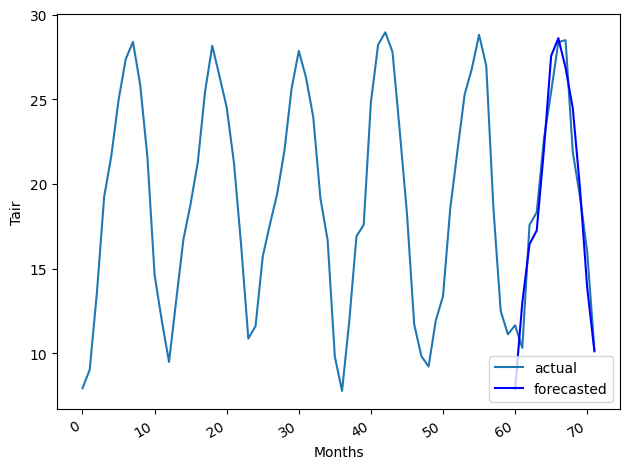

In [15]:
# Visualize predictions
fig, ax = plt.subplots()

# Plot actual data
ax.plot(df.Tair.tolist(), label='actual')

# Plot forecasted data with adjusted x-axis values
ax.plot(forecast_x_values, forecast_df.Tair, 'b-', label='forecasted')

ax.set_xlabel('Months')
ax.set_ylabel('Tair')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

# Show the plot
plt.show()

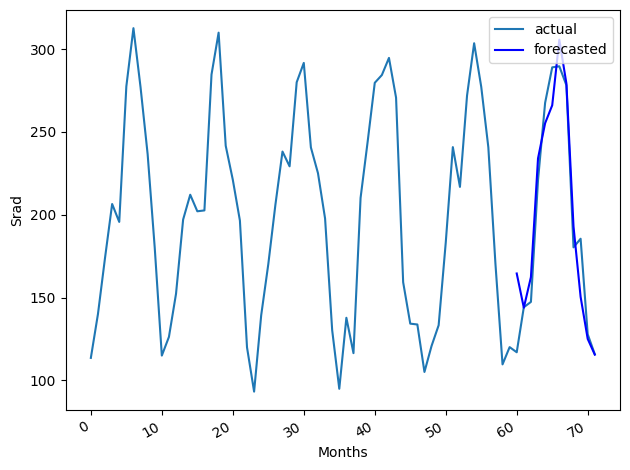

In [16]:
# Visualize predictions
fig, ax = plt.subplots()

# Plot actual data
ax.plot(df.Srad.tolist(), label='actual')

# Plot forecasted data with adjusted x-axis values
ax.plot(forecast_x_values, forecast_df.Srad, 'b-', label='forecasted')

ax.set_xlabel('Months')
ax.set_ylabel('Srad')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

# Show the plot
plt.show()

In [17]:
mse_srad = mean_squared_error(forecast_df.Srad,df.Srad.tolist()[60:])
mse_srad

415.44848046271994

In [18]:
mse_tair = mean_squared_error(forecast_df.Tair,df.Tair.tolist()[60:])
mse_tair

3.5846670150519677